### DecisionTree (의사 결정 나무)

- parameter
    - criterion
        - 분류
            - default: gini
            - other: entropy(성능 향상 속도 감소), log_loss(확률적 분류)
        - 회귀
            - default: squared_error(MSE)
            - other: absolute_error(MAE), friedman_mes(분산 감소 기반)
        
    - spliter
        - default: best
        - 분할 시 feature(컬럼) 선택 방식
        - best
            - 가장 좋은 feature 선택
        - other: random
            - 무작위 feature 선택(다양성 향상을 위함 / 여러 학습을 통한 예측(앙상블))
    
    - max_depth
        - default: None
        - 트리의 최대 깊이 제한
        - None인 경우, leaf node까지 계속 분할 → 과적합 위험
    
    - min_sample_split
        - default: 2
        - node를 분할하기 위한 최소 샘플 수
    
    - min_samples_leaf
        - default: 1
        - leaf node가 되기 위한 최소 샘플 수

    - max_features
        - default: None
        - 최적으로 분할 시 고려할 feature 개수
        - None
            - 모든 feature 사용
        - sqrt
            - feature 개수에서 루트를 입혀서 사용
        - log2
            - feature 개수에서 로그2를 입혀서 사용
        - 숫자 형태로 고정된 값 사용 가능
    
    - min_impurity_decrease
        - default: 0.0
        - 불순도 감소량이 해당 매개변수의 인자값 이상일 때만 데이터 분할 수행
    
    - ccp_alpha
        - default: 0.0
        - 비용-복잡도 가지치기 매개변수
        - 값이 커지는 경우 트리의 단순화

- 속성
    - tree_
        - 트리 구조에 대한 상세 객체
    - classes_
        - 분류 문제에서 클래스의 목록 (정답 리스트)
    - n_classes_
        - 클래스의 개수
    - n_features_in_
        - 입력되는 데이터의 feature 개수
    - feature_importances_
        - 각 feature들의 중요도 (중요도들의 합은 1)

- 메서드
    - fit()
        - 모델 학습
    - predict()
        - 학습된 모델로 예측
    - score()
        - 분류에서는 accuracy, 회귀에서는 r2 score
    - predict_proba()
        - 분류에서만 사용
        - 각 클래스별 예측 확률

In [380]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

In [381]:
iris = pd.read_csv('../csv/iris.csv')

In [382]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.drop('species', axis = 1),
    iris['species'],
    test_size = 0.2,
    random_state = 42,
    stratify = iris['species']
)

max_depth 5, 3, 1을 기준으로 3개의 모델을 생성  
score(X_train, y_train) 함수를 이용하여 학습된 데이터에서 정확도를 확인  
X_test를 이용하여 예측 → f1_score를 이용하여 모델의 성능 확인

In [383]:
tree1 = DecisionTreeClassifier(max_depth=1, random_state=42)
tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree5 = DecisionTreeClassifier(max_depth=5, random_state=42)

In [384]:
tree1.fit(X_train, y_train)
tree3.fit(X_train, y_train)
tree5.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [385]:
print(tree1.score(X_train, y_train))
print(tree3.score(X_train, y_train))
print(tree5.score(X_train, y_train))

0.6666666666666666
0.9833333333333333
1.0


In [386]:
pred1 = tree1.predict(X_test)
pred3 = tree3.predict(X_test)
pred5 = tree5.predict(X_test)


In [387]:
print(f1_score(y_test, pred1, average='micro'))
print(f1_score(y_test, pred3, average='micro'))
print(f1_score(y_test, pred5, average='micro'))

0.6666666666666666
0.9666666666666667
0.9333333333333333


In [388]:
print(f1_score(y_test, pred1, average='macro'))
print(f1_score(y_test, pred3, average='macro'))
print(f1_score(y_test, pred5, average='macro'))

0.5555555555555555
0.9665831244778612
0.9333333333333332


In [389]:
print(f1_score(y_test, pred1, average='weighted'))
print(f1_score(y_test, pred3, average='weighted'))
print(f1_score(y_test, pred5, average='weighted'))

0.5555555555555555
0.9665831244778613
0.9333333333333333


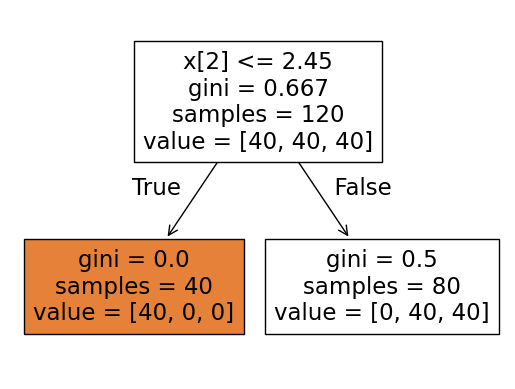

In [390]:
plot_tree(tree1, filled=True)
plt.show()

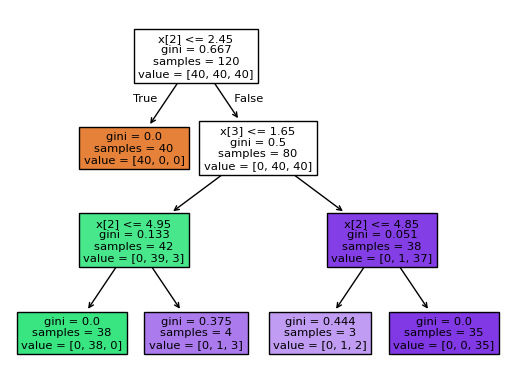

In [391]:
plot_tree(tree3, filled=True)
plt.show()

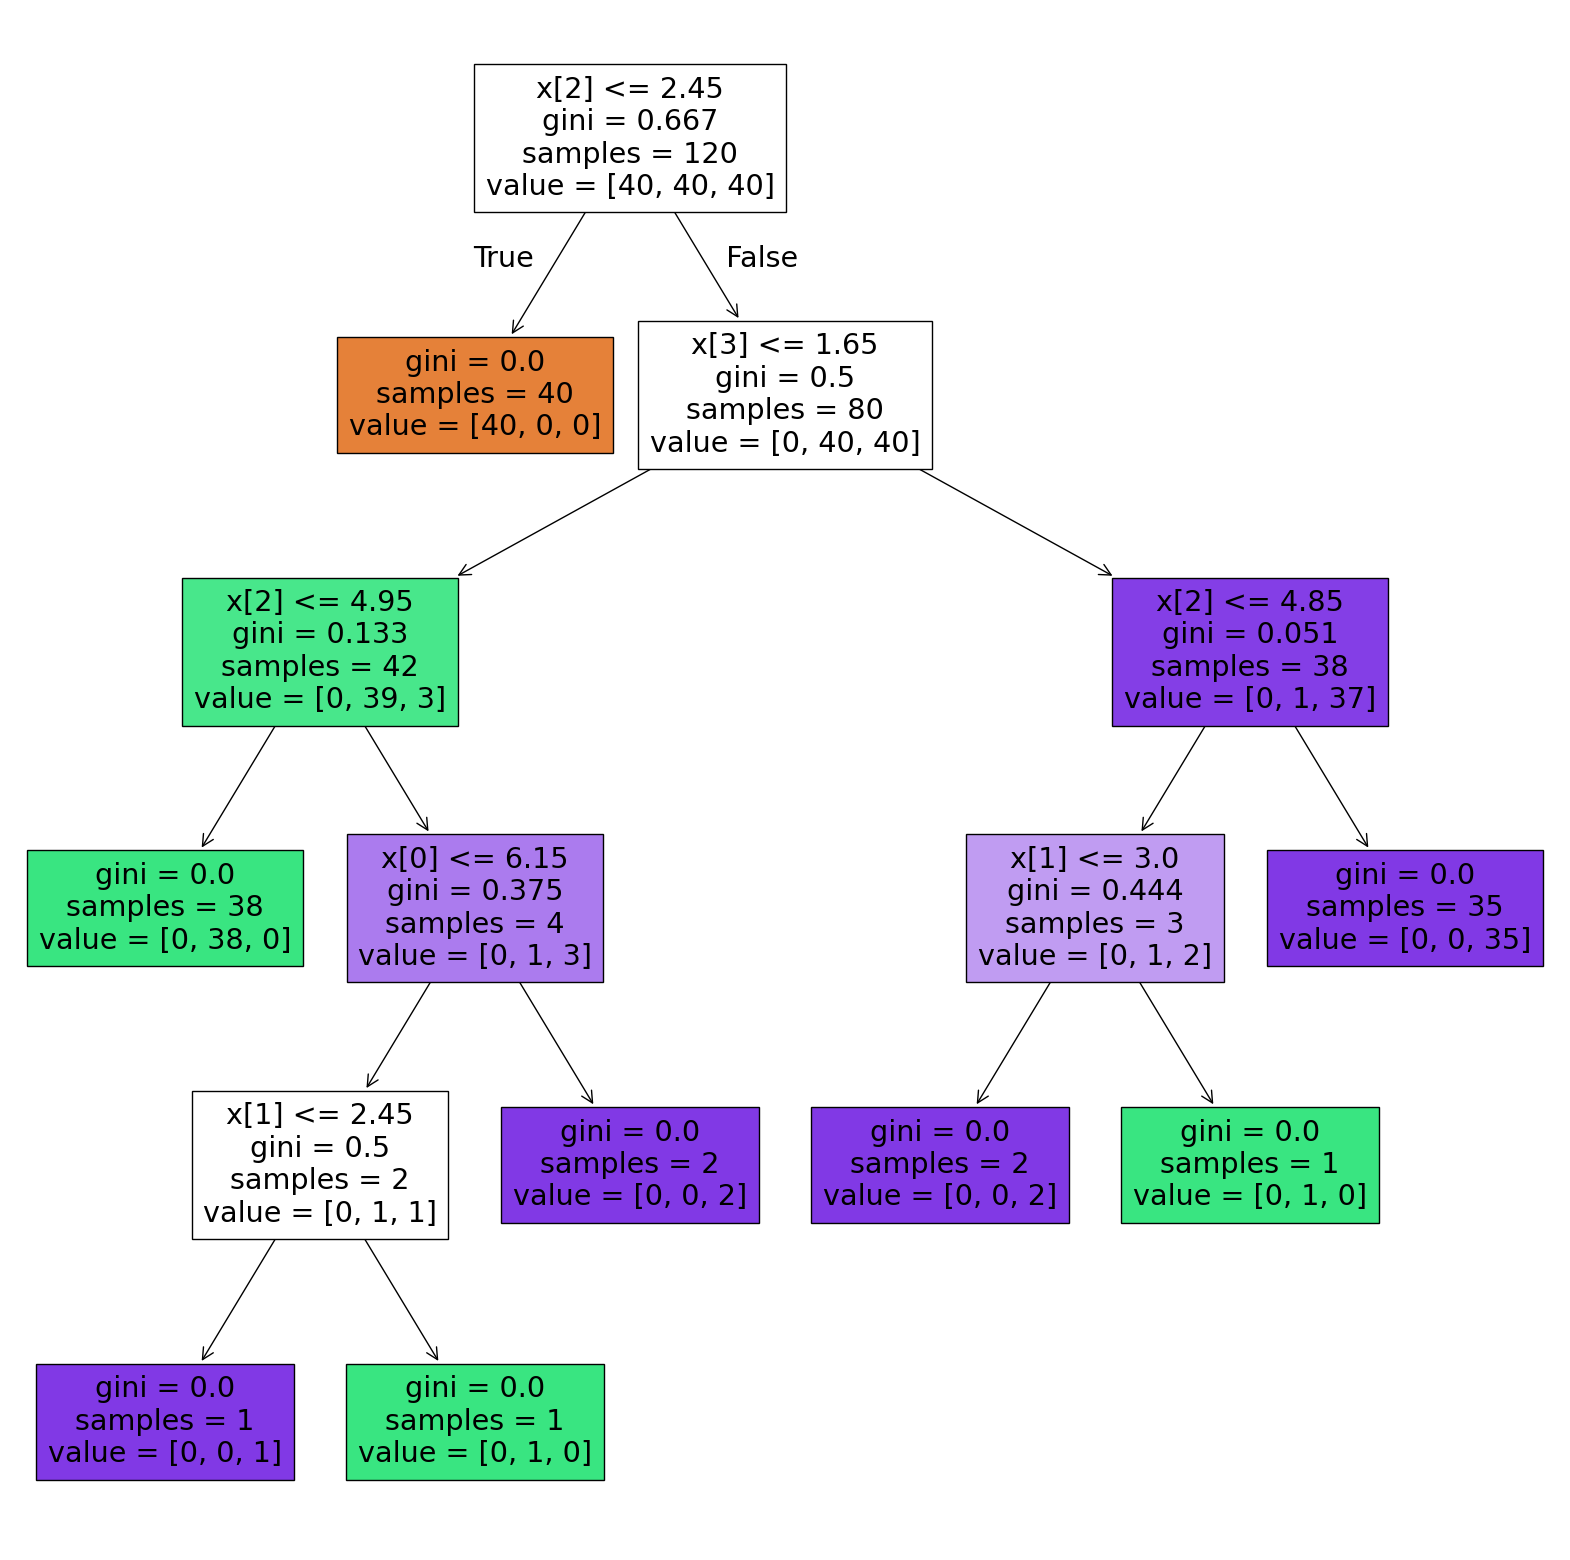

In [392]:
plt.figure(figsize=(20,20))
plot_tree(tree5, filled=True)
plt.show()

In [393]:
# min_samples_split = 5 모델 설정

clf = DecisionTreeClassifier(max_depth=3, min_samples_split=45, random_state=42)

In [394]:
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",45
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

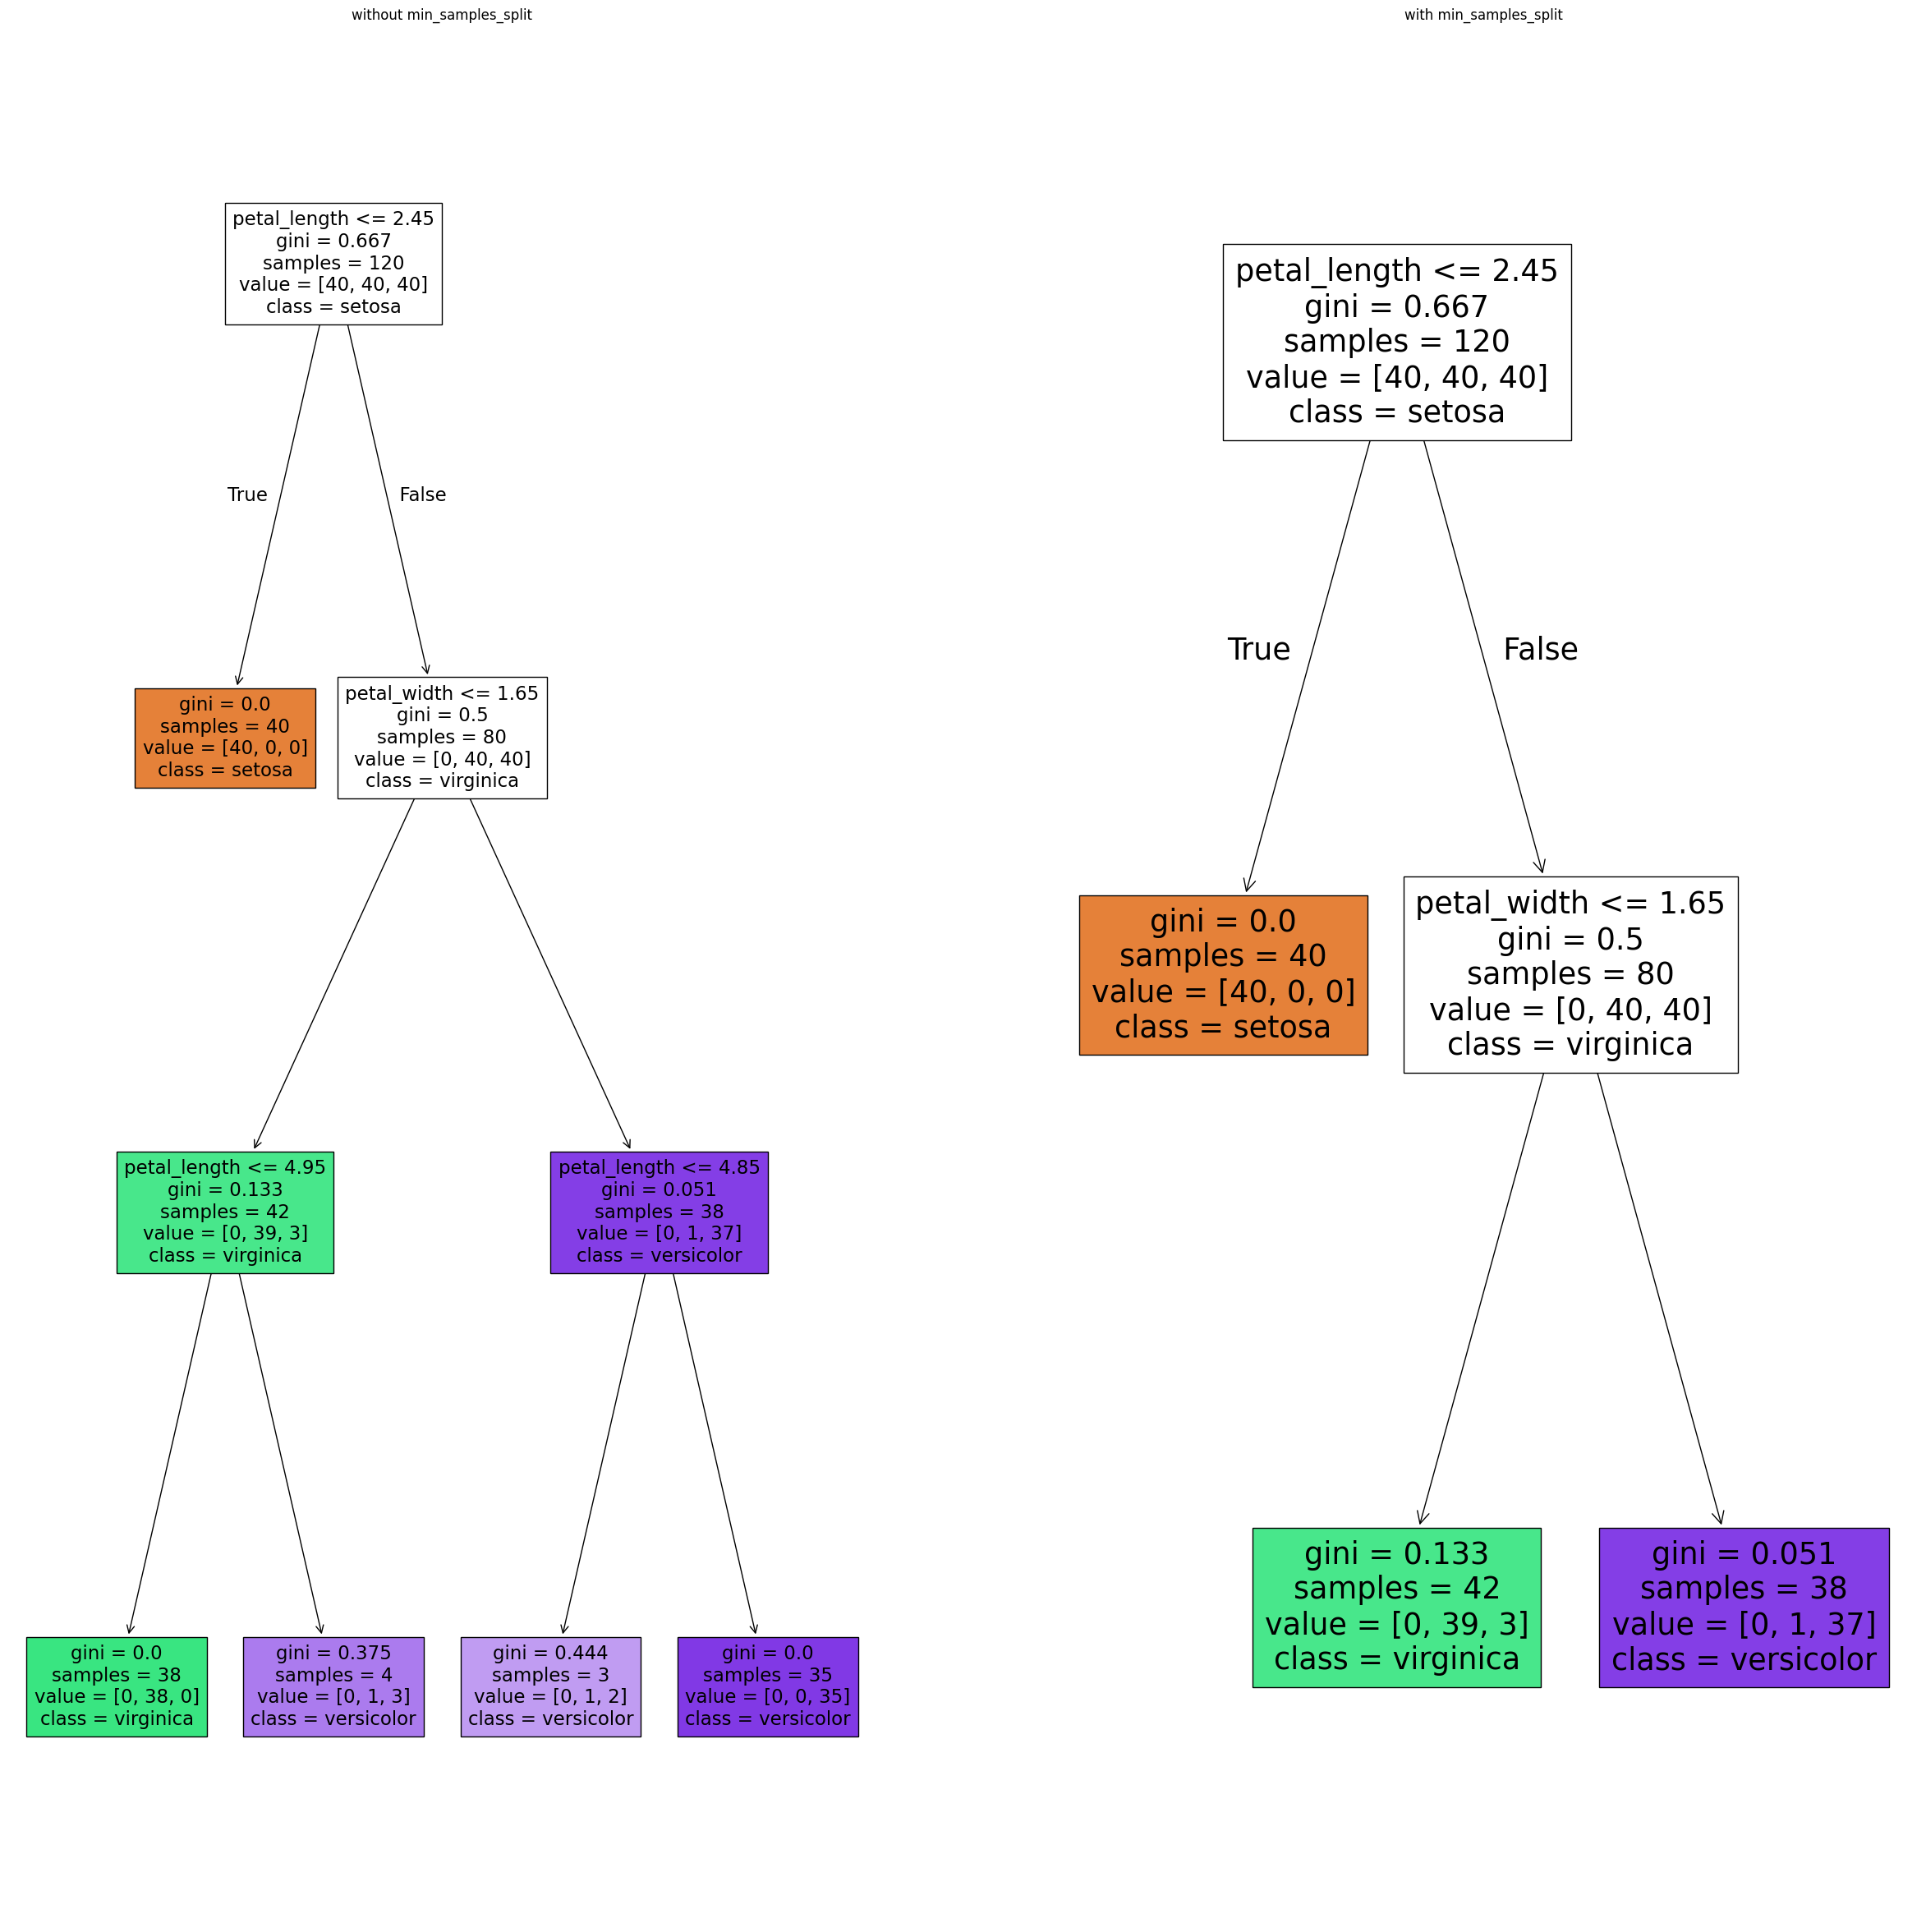

In [395]:
feature_names = X_train.columns
class_names = y_train.unique()

plt.figure(figsize=(30, 30))
plt.subplot(1, 2, 1)
plot_tree(tree3, feature_names=feature_names, class_names=class_names, filled = True)
plt.title('without min_samples_split')
plt.subplot(1, 2, 2)
plot_tree(clf, feature_names=feature_names, class_names=class_names, filled = True)
plt.title('with min_samples_split')
plt.show()

In [396]:
print(f1_score(y_test, clf.predict(X_test), average='micro'))

0.9333333333333333


이진 분류

In [397]:
df = pd.read_csv('../data/diabetes.csv')

In [398]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [399]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [400]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [401]:
flag = df['Glucose'] == 0

df.loc[flag,]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [402]:
flag = df['BloodPressure'] == 0

len(df.loc[flag,])

35

In [403]:
flag = df['BMI'] == 0

len(df.loc[flag,])

11

In [404]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [405]:
# 독립변수, 종속변수 / train, test split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Outcome', axis=1),
    df['Outcome'],
    test_size = 0.3,
    random_state = 42
)

In [406]:
# 깊이가 3, 5, 7

clf_3 = DecisionTreeClassifier(max_depth = 3, random_state = 42)
clf_5 = DecisionTreeClassifier(max_depth = 5, random_state = 42)
clf_7 = DecisionTreeClassifier(max_depth = 7, random_state = 42)

In [407]:
clf_3.fit(X_train, y_train)
clf_5.fit(X_train, y_train)
clf_7.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [408]:
print(clf_3.score(X_test, y_test))
print(clf_5.score(X_test, y_test))
print(clf_7.score(X_test, y_test))

0.7186147186147186
0.7489177489177489
0.7012987012987013


In [409]:
pred = clf_5.predict(X_test)

In [410]:
confusion_matrix(y_test, pred)

array([[129,  22],
       [ 36,  44]])

In [411]:
print('정확도:', accuracy_score(y_test,pred))
print('정밀도:', precision_score(y_test,pred))
print('재현율:', recall_score(y_test,pred))
print('f1_score:', f1_score(y_test,pred))

정확도: 0.7489177489177489
정밀도: 0.6666666666666666
재현율: 0.55
f1_score: 0.6027397260273972


In [412]:
clf_5.feature_importances_

array([0.        , 0.53088781, 0.03238874, 0.00831091, 0.        ,
       0.1905986 , 0.05494944, 0.18286451])

**모델의 성능을 높여보자**  
1. 혈당, 혈압, BMI 데이터 컬럼에서 0인 데이터를 해당 컬럼의 평균으로 대체
2. 스케일링 사용
    - 원본 데이터를 사용하여 모델 성능 확인
    - 스케일링 데이터를 사용하여 모델 성능 확인

In [413]:
flag1 = df['Glucose'] == 0
flag2 = df['BloodPressure'] == 0
flag3 = df['BMI'] == 0

In [414]:
mean_value = df.loc[~flag, 'Glucose'].mean()
df.loc[flag, 'Glucose'] = int(mean_value)

In [415]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [416]:
# BloodPressure 컬럼에서 0인 데이터를 결측치로 대체

df['BloodPressure'].mean()

np.float64(69.10546875)

In [417]:
df.loc[flag2, 'BloodPressure'] = np.nan

In [418]:
mean_value2 = df['BloodPressure'].mean()

In [419]:
df['BloodPressure'] = df['BloodPressure'].fillna(mean_value2)

In [420]:
# BMI 값에서 0은 최빈값으로 채운다.

value3 = df['BMI'].value_counts().index[0]

In [421]:
df.loc[flag3, 'BMI'] = value3

In [422]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.134115,72.405184,20.536458,79.799479,32.450911,0.471876,33.240885,0.348958
std,3.369578,31.830696,12.096346,15.952218,115.244002,6.875366,0.331329,11.760232,0.476951
min,0.000000,0.000000,24.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,118.000000,72.202592,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


수정한 데이터를 이용하여 깊이가 7인 의사결정나무에 학습 및 예측, 평가지표 확인

In [423]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Outcome', axis=1),
    df['Outcome'],
    test_size = 0.3,
    random_state = 42
)

In [424]:
clf_7.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [425]:
pred = clf_7.predict(X_test)

In [426]:
def score_print(y, pred):
    print('정확도:', accuracy_score(y,pred))
    print('정밀도:', precision_score(y,pred))
    print('재현율:', recall_score(y,pred))
    print('f1_score:', f1_score(y,pred))

In [427]:
score_print(y_test, pred)

정확도: 0.670995670995671
정밀도: 0.5196078431372549
재현율: 0.6625
f1_score: 0.5824175824175825


스케일링 사용 시

In [428]:
from sklearn.preprocessing import StandardScaler

In [429]:
stdScaler = StandardScaler()
X_train_sc = stdScaler.fit_transform(X_train)
X_test_sc = stdScaler.transform(X_test)

In [430]:
clf_7.fit(X_train_sc, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [431]:
pred_sc = clf_7.predict(X_test_sc)

In [432]:
score_print(y_test, pred_sc)

정확도: 0.670995670995671
정밀도: 0.5196078431372549
재현율: 0.6625
f1_score: 0.5824175824175825
